In [1]:
import numpy as np
from svm import SVM
import sklearn as sk
import matplotlib.pyplot as plt


In [2]:
X, y =sk.datasets.make_classification(
    n_samples=50, n_features=2, n_classes=2,
    n_informative=2, n_redundant=0, random_state=42
    )
y = 2*y - 1  # make it -1 or 1
X[y == 1] += 1  # shift class 1 to make it linearly separable

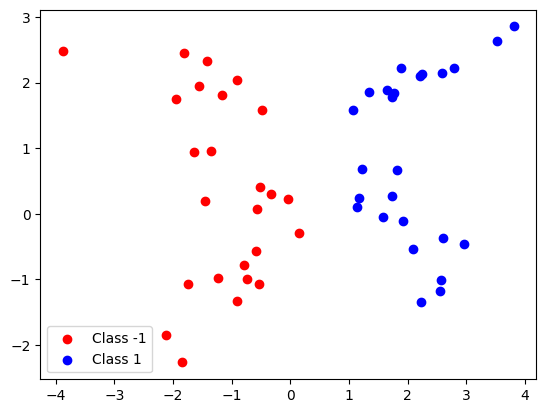

In [3]:
plt.figure()
plt.scatter(X[:, 0][y == -1], X[:, 1][y == -1], c='r', label='Class -1')
plt.scatter(X[:, 0][y == 1], X[:, 1][y == 1], c='b', label='Class 1')
plt.legend()
plt.show()

In [4]:
svm = SVM(C=1)

In [5]:
svm.fit(X, y, lr=0.01, epochs=100)

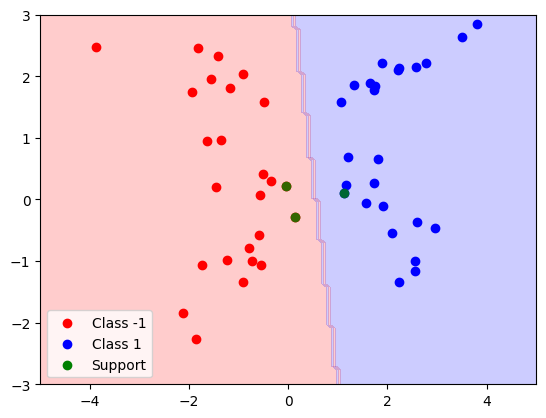

In [6]:
x_min = -5
x_max = 5
y_min = -3
y_max = 3
N = 100

xv, yv = np.meshgrid(np.linspace(x_min, x_max, N), np.linspace(y_min, y_max, N))
nx, ny = xv.shape

zv = np.zeros((nx, ny))
for i in range(nx):
    for j in range(ny):
        zv[i, j] = svm.predict(np.array([[xv[i, j], yv[i, j]]]))[0]

support_vectors = svm.support_vectors(X, y)

plt.figure()
plt.scatter(X[:, 0][y == -1], X[:, 1][y == -1], c='r', label='Class -1')
plt.scatter(X[:, 0][y == 1], X[:, 1][y == 1], c='b', label='Class 1')
plt.scatter(X[:, 0][support_vectors], X[:, 1][support_vectors], c='g', label='Support')
plt.contourf(xv, yv, zv, 2, alpha=0.2, colors=['r', 'b'])
plt.legend()
plt.show()

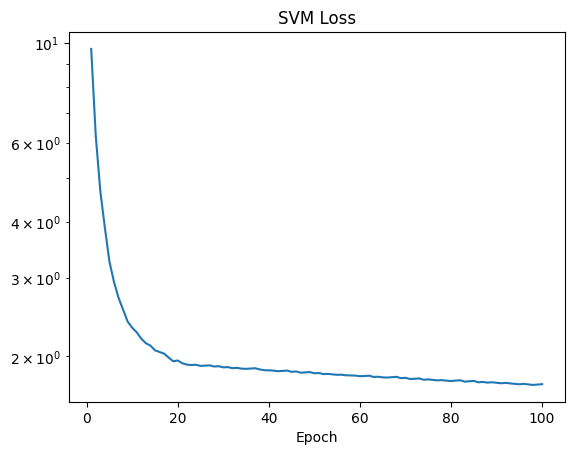

In [7]:
plt.figure()
plt.semilogy(np.arange(1, len(svm.loss) + 1), svm.loss)
plt.xlabel('Epoch')
plt.title('SVM Loss')
plt.show()

# Kernel Method

In [8]:
from svm import KernelSVM, RBFKernel

rbf = RBFKernel(gamma=1.0)
svm = KernelSVM(C=1.0, kernel=rbf)

In [9]:
svm.fit(X, y)

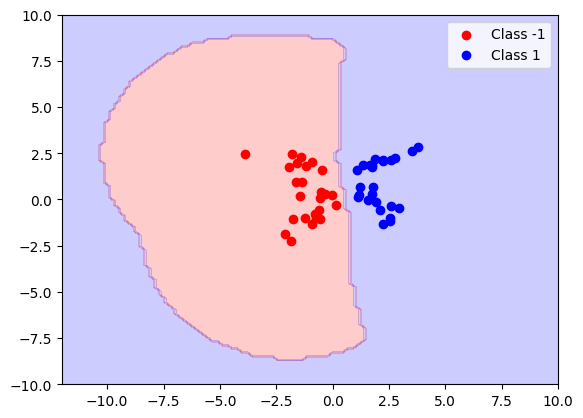

In [10]:
import numpy as np
x_min = -12
x_max = 10
y_min = -10
y_max = 10
N = 100

xv, yv = np.meshgrid(np.linspace(x_min, x_max, N), np.linspace(y_min, y_max, N))
nx, ny = xv.shape

zv = np.zeros((nx, ny))
for i in range(nx):
    for j in range(ny):
        zv[i, j] = svm.predict(np.array([[xv[i, j], yv[i, j]]]))[0]

plt.figure()
plt.scatter(X[:, 0][y == -1], X[:, 1][y == -1], c='r', label='Class -1')
plt.scatter(X[:, 0][y == 1], X[:, 1][y == 1], c='b', label='Class 1')
plt.contourf(xv, yv, zv, 3, alpha=0.2, colors=['r', 'b'])
plt.legend()
plt.show()

# One-vs-Rest

In [11]:
def OvR(X, y, make_model, **fit_kwargs):
    classes = np.unique(y)
    models = []
    for c in classes:
        z = np.where(y == c, 1, -1)
        model = make_model()
        model.fit(X, z, **fit_kwargs)
        models.append(model)

    def predict(X_new):
        scores = np.column_stack([m.decision_function(X_new) for m in models])
        return classes[np.argmax(scores, axis=1)]

    return predict


OvR accuracy: 1.000


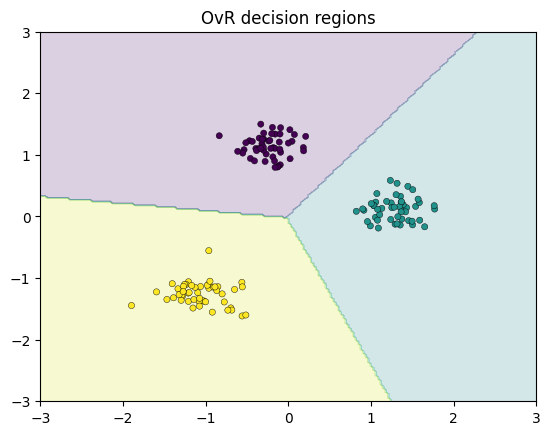

In [12]:
X, y = sk.datasets.make_blobs(n_samples=150, centers=3, cluster_std=1.2, random_state=42)
X = (X - X.mean(0)) / X.std(0)
ovr = OvR(X, y, lambda: SVM(C=1))
print(f'OvR accuracy: {(ovr(X) == y).mean():.3f}')


xv, yv = np.meshgrid(np.linspace(-3, 3, 200), np.linspace(-3, 3, 200))
zv = ovr(np.c_[xv.ravel(), yv.ravel()]).reshape(xv.shape)

plt.figure()
plt.contourf(xv, yv, zv, alpha=0.2, cmap='viridis')
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='viridis', s=20, edgecolors='k', linewidths=0.3)
plt.title('OvR decision regions')
plt.show()

# One-vs-One

In [13]:
def OvO(X, y, make_model, **fit_kwargs):
    classes = np.unique(y)
    models = []
    for i in range(len(classes)):
        for j in range(i + 1, len(classes)):
            c1, c2 = classes[i], classes[j]
            mask = (y == c1) | (y == c2)          # only the two classes
            z = np.where(y[mask] == c1, 1, -1)
            model = make_model()
            model.fit(X[mask], z, **fit_kwargs)   # forward lr / epochs / ... to the base model
            models.append((i, j, model))          # remember which classes this pair separates

    def predict(X_new):                           # closure: majority vote over pairwise models
        votes = np.zeros((X_new.shape[0], len(classes)), dtype=int)
        for i, j, model in models:
            pred = model.predict(X_new)            # +1 -> class i, -1 -> class j
            votes[pred == 1, i] += 1
            votes[pred == -1, j] += 1
        return classes[np.argmax(votes, axis=1)]

    return predict


OvO accuracy: 1.000


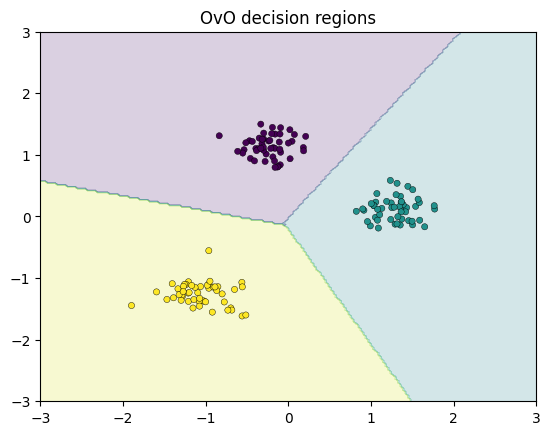

In [14]:
ovo = OvO(X, y, lambda: SVM(C=1))
print(f'OvO accuracy: {(ovo(X) == y).mean():.3f}')

xv, yv = np.meshgrid(np.linspace(-3, 3, 200), np.linspace(-3, 3, 200))
zv = ovo(np.c_[xv.ravel(), yv.ravel()]).reshape(xv.shape)

plt.figure()
plt.contourf(xv, yv, zv, alpha=0.2, cmap='viridis')
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='viridis', s=20, edgecolors='k', linewidths=0.3)
plt.title('OvO decision regions')
plt.show()

linear OvO accuracy: 0.550
RBF    OvO accuracy: 1.000


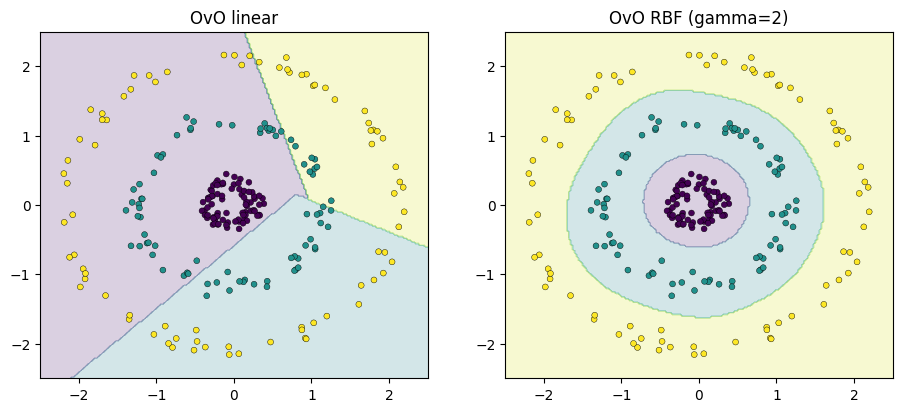

In [15]:
rng = np.random.default_rng(0)
N_PER_CLASS = 80
pts, lab = [], []
for k, r in enumerate([0.5, 2.0, 3.5]):
    theta = rng.uniform(0, 2 * np.pi, N_PER_CLASS)
    radius = r + rng.normal(0, 0.12, N_PER_CLASS)
    pts.append(np.c_[radius * np.cos(theta), radius * np.sin(theta)])
    lab += [k] * N_PER_CLASS
X = np.vstack(pts)
y = np.array(lab)
X = (X - X.mean(0)) / X.std(0)

lin_clf = OvO(X, y, lambda: SVM(C=1), lr=0.01, epochs=200)
rbf_clf = OvO(X, y, lambda: KernelSVM(C=1, kernel=RBFKernel(gamma=2.0)), lr=0.01, epochs=200)
print(f'linear OvO accuracy: {(lin_clf(X) == y).mean():.3f}')
print(f'RBF    OvO accuracy: {(rbf_clf(X) == y).mean():.3f}')

xv, yv = np.meshgrid(np.linspace(-2.5, 2.5, 200), np.linspace(-2.5, 2.5, 200))
grid = np.c_[xv.ravel(), yv.ravel()]

fig, ax = plt.subplots(1, 2, figsize=(11, 4.5))
for axe, clf, name in [(ax[0], lin_clf, 'linear'), (ax[1], rbf_clf, 'RBF (gamma=2)')]:
    axe.contourf(xv, yv, clf(grid).reshape(xv.shape), alpha=0.2, cmap='viridis')
    axe.scatter(X[:, 0], X[:, 1], c=y, cmap='viridis', s=18, edgecolors='k', linewidths=0.3)
    axe.set_title(f'OvO {name}')
plt.show()